In [2]:
import pandas as pd
df = pd.read_csv("train.csv")
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [4]:
df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [5]:
df.isnull().sum()

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

In [6]:
df.groupby('class').count()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
class,,,,,,,,,,,
GALAXY,377480,377480,377480,377480,377480,377480,377480,377480,377480,377480,377480
QSO,117143,117143,117143,117143,117143,117143,117143,117143,117143,117143,117143
STAR,82724,82724,82724,82724,82724,82724,82724,82724,82724,82724,82724


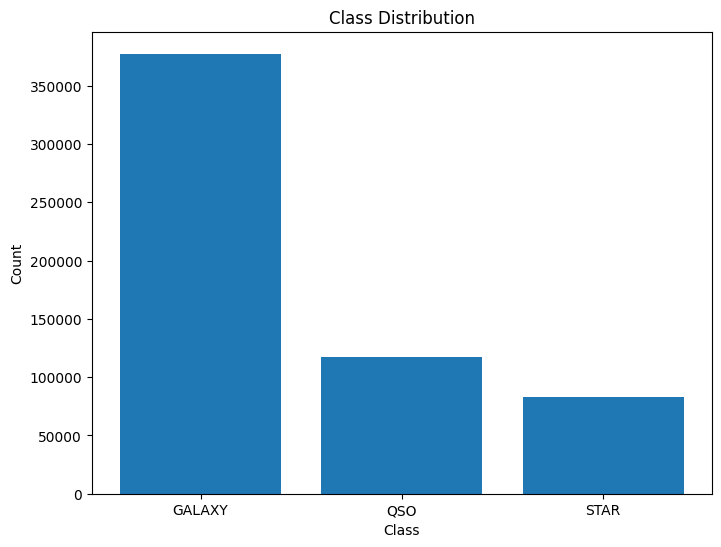

In [7]:
#class distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.bar(df['class'].value_counts().index, df['class'].value_counts().values)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


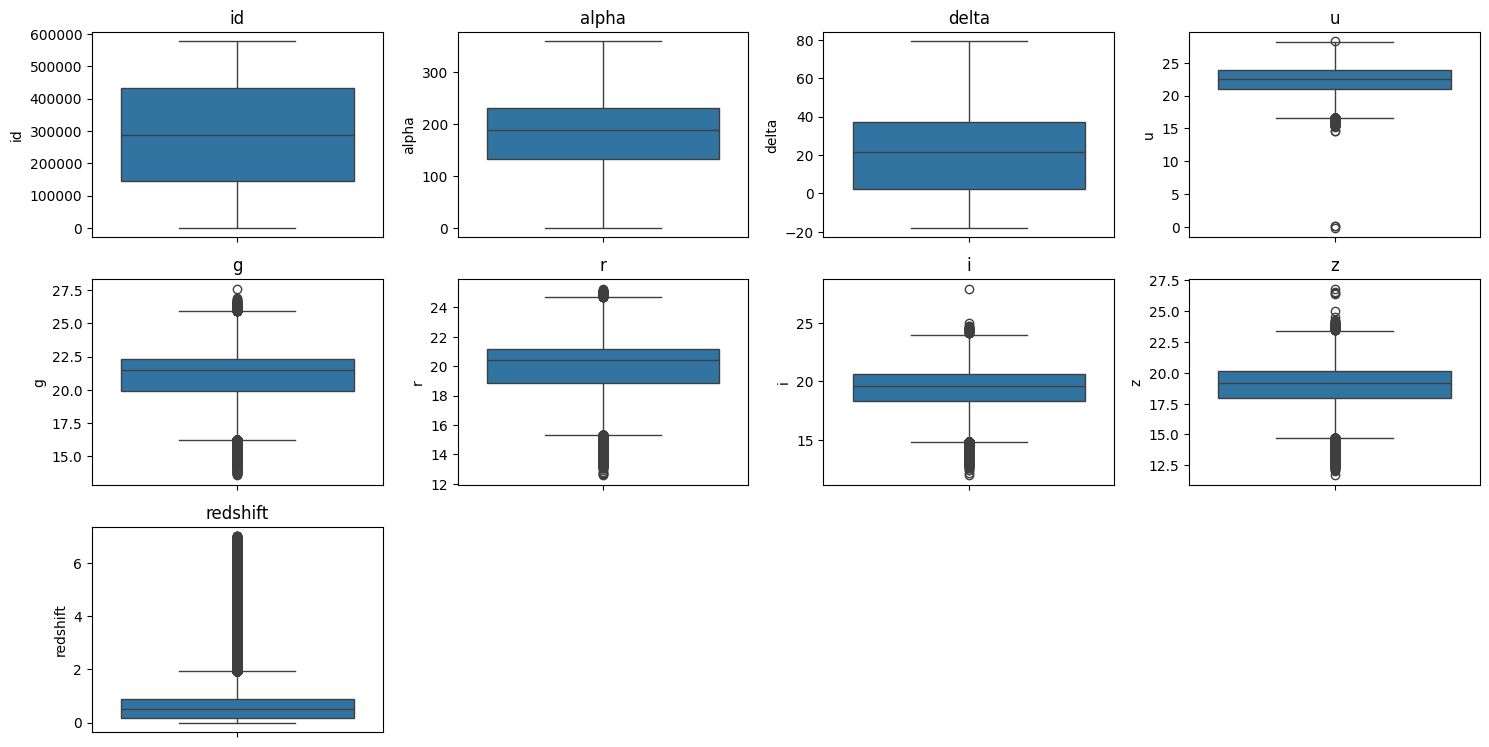

In [8]:
import seaborn as sns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
#handling outliers using IQR method
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |(df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [10]:
# creating a ML preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

target_col = 'class'

X=df.drop(columns=[target_col,'id'])

y=df[target_col]
le=LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [11]:
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', DecisionTreeClassifier(max_depth=15, min_samples_split=10, min_samples_leaf=4, random_state=42))])
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_pipeline, X, y_encoded, cv=skf, scoring='accuracy')
print("Fold accuracies:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

 
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Fold accuracies: [0.94645151 0.94485939 0.94475392 0.9456552  0.94644141]
Mean CV Accuracy: 0.9456
Std Dev: 0.0007
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.96     75302
         QSO       0.91      0.91      0.91     12869
        STAR       0.88      0.87      0.88     16127

    accuracy                           0.94    104298
   macro avg       0.92      0.92      0.92    104298
weighted avg       0.94      0.94      0.94    104298

Balanced Accuracy: 0.9163069028047918
Confusion Matrix:
 [[72724   947  1631]
 [  878 11751   240]
 [ 1933   163 14031]]


redshift                          0.352227
spectral_type_M                   0.292646
z                                 0.110237
g                                 0.071399
u                                 0.064624
alpha                             0.035310
spectral_type_G/K                 0.028167
delta                             0.024340
i                                 0.009936
r                                 0.009503
galaxy_population_Blue_Cloud      0.000889
galaxy_population_Red_Sequence    0.000512
spectral_type_A/F                 0.000147
spectral_type_O/B                 0.000063
dtype: float64


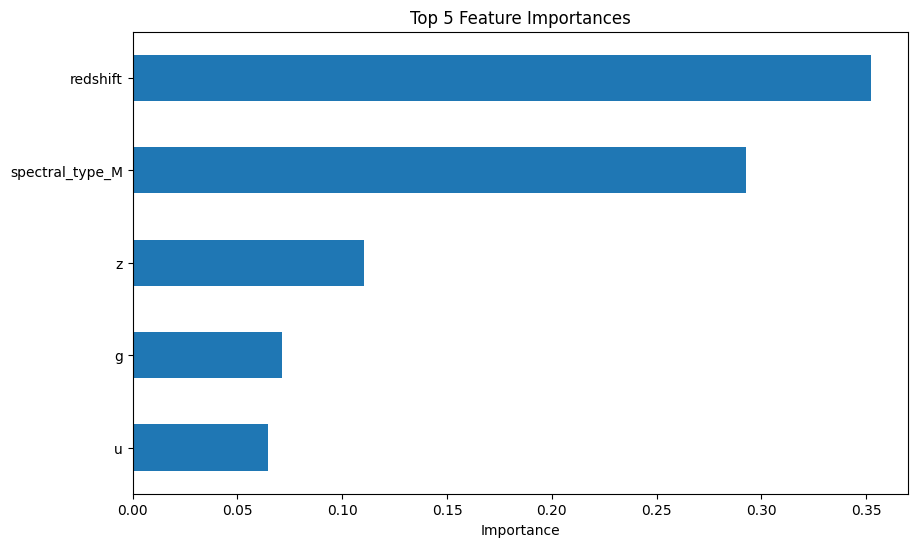

Highly correlated (redundant) feature pairs (>0.9): [('r', 'g', np.float64(0.9217930868637809)), ('i', 'r', np.float64(0.9557598436632574)), ('z', 'r', np.float64(0.9151287420747537)), ('z', 'i', np.float64(0.9676611011848676))]


In [12]:
# finding feature importance 
import numpy as np
cat_feature_names = []
if len(categorical_features) > 0:
    cat_feature_names = list(
        model_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )

all_feature_names = list(numeric_features) + cat_feature_names
importances = model_pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
print(feat_imp.head(15))

plt.figure(figsize=(10, 6))
feat_imp.head(5).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 5 Feature Importances")
plt.xlabel("Importance")
plt.show()

#Redundant features (highly correlated pairs)
corr_matrix = df[numeric_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant = [(col, row, upper.loc[row, col]) 
             for col in upper.columns for row in upper.index 
             if upper.loc[row, col] > 0.9]
print("Highly correlated (redundant) feature pairs (>0.9):", redundant)

In [13]:
# applying grid search to find the best hyperparameters for the Decision Tree Classifier
from sklearn.model_selection import GridSearchCV
param_grid = {
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
}
cv_grid_search = GridSearchCV(model_pipeline, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
cv_grid_search.fit(X_train, y_train)
print("Best hyperparameters:", cv_grid_search.best_params_)

Best hyperparameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10}


In [14]:
# Training a lightweight Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Reduced grid: 8 combinations instead of 36
param_grid_rf = {
    'classifier__max_depth': [8, 10],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 4],
}
cv_grid_search_rf = GridSearchCV(
    model_pipeline_rf,
    param_grid_rf,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)
cv_grid_search_rf.fit(X_train, y_train)
print("Best hyperparameters for Random Forest:", cv_grid_search_rf.best_params_)

C:\Users\LOQ\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
13 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\LOQ\AppData\Roaming\Python\Python310\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
  File "C:\Users\LOQ\AppData\Roaming\Python\Python310\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
  File "C:\Users\LOQ\AppData\Roaming\Python\Python310\site-packages\joblib\para

Best hyperparameters for Random Forest: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}


In [15]:
# finding the classification report for the best Random Forest model
best_rf_model = cv_grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     75302
         QSO       0.92      0.91      0.92     12869
        STAR       0.88      0.86      0.87     16127

    accuracy                           0.94    104298
   macro avg       0.92      0.91      0.92    104298
weighted avg       0.94      0.94      0.94    104298

Balanced Accuracy: 0.91267716115585
Confusion Matrix:
 [[72949   911  1442]
 [  675 11736   458]
 [ 2204    97 13826]]


In [16]:
# implementig boosting using AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
model_pipeline_ab = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        n_estimators=100,
        learning_rate=1,
        random_state=42
    ))
])
param_grid_ab = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.01, 0.1, 1]
}
cv_grid_search_ab = GridSearchCV(
    model_pipeline_ab,
    param_grid_ab,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)
cv_grid_search_ab.fit(X_train, y_train)
print("Best hyperparameters for AdaBoost:", cv_grid_search_ab.best_params_)


Best hyperparameters for AdaBoost: {'classifier__learning_rate': 1, 'classifier__n_estimators': 100}


In [17]:
#finding the classification report , Balanced Accuracy and confusion matrix for the best AdaBoost model
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
best_ab_model = cv_grid_search_ab.best_estimator_
y_pred_ab = best_ab_model.predict(X_test)
print(classification_report(y_test, y_pred_ab, target_names=le.classes_))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_ab))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ab))

              precision    recall  f1-score   support

      GALAXY       0.95      0.95      0.95     75302
         QSO       0.86      0.85      0.86     12869
        STAR       0.82      0.83      0.82     16127

    accuracy                           0.92    104298
   macro avg       0.88      0.88      0.88    104298
weighted avg       0.92      0.92      0.92    104298

Balanced Accuracy: 0.8756965676504037
Confusion Matrix:
 [[71275  1681  2346]
 [ 1258 10979   632]
 [ 2700    83 13344]]


In [18]:
#implementing XGBoost Classifier
from xgboost import XGBClassifier
model_pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.2,
        max_depth=10,
        random_state=42,
        eval_metric='mlogloss',
        tree_method='hist',
        device='cpu',
        n_jobs=1
    ))
])
param_grid_xgb = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 6, 10]
}
grid_search_xgb = GridSearchCV(
    model_pipeline_xgb,
    param_grid_xgb,
    cv=skf,
    scoring='accuracy',
    n_jobs=1,
    error_score='raise'
 )
grid_search_xgb.fit(X_train, y_train)
print("Best hyperparameters for XGBoost:", grid_search_xgb.best_params_)


Best hyperparameters for XGBoost: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 10, 'classifier__n_estimators': 100}


In [19]:
# finding the classification report, confusion matrix and Best Accuracy score  for the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print("Best Accuracy Score:", grid_search_xgb.best_score_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     75302
         QSO       0.93      0.93      0.93     12869
        STAR       0.92      0.92      0.92     16127

    accuracy                           0.96    104298
   macro avg       0.94      0.94      0.94    104298
weighted avg       0.96      0.96      0.96    104298

Best Accuracy Score: 0.9632563761980941
Confusion Matrix:
 [[73568   708  1026]
 [  642 11997   230]
 [ 1143   149 14835]]


In [20]:
# boosting using Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
model_pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=2,
        random_state=42
    ))
])
model_pipeline_gb.fit(X_train, y_train)
y_pred_gb = model_pipeline_gb.predict(X_test)
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

              precision    recall  f1-score   support

      GALAXY       0.94      0.97      0.96     75302
         QSO       0.93      0.87      0.89     12869
        STAR       0.87      0.81      0.84     16127

    accuracy                           0.93    104298
   macro avg       0.91      0.88      0.90    104298
weighted avg       0.93      0.93      0.93    104298

Balanced Accuracy: 0.8824297757690917
Confusion Matrix:
 [[72880   796  1626]
 [ 1347 11145   377]
 [ 2913    96 13118]]


In [21]:
# implementing stacking using StackingClassifier
from sklearn.ensemble import StackingClassifier
base_estimators = ['XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier']
metaclassifier = RandomForestClassifier(n_estimators=50,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
        )
model_pipeline_stack = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=[
            ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.2, max_depth=10, random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
            ('ab', AdaBoostClassifier(n_estimators=100, learning_rate=1, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=2, random_state=42))
        ],
        final_estimator=metaclassifier,
        cv=skf,
        n_jobs=-1
    ))])
model_pipeline_stack.fit(X_train, y_train)
y_pred_stack = model_pipeline_stack.predict(X_test)
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_stack))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))

              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     75302
         QSO       0.93      0.94      0.94     12869
        STAR       0.92      0.92      0.92     16127

    accuracy                           0.96    104298
   macro avg       0.94      0.95      0.95    104298
weighted avg       0.96      0.96      0.96    104298

Balanced Accuracy: 0.9452482920668892
Confusion Matrix:
 [[73541   727  1034]
 [  607 12064   198]
 [ 1142   121 14864]]


In [22]:
# Extract fitted pieces from your best pipeline
best_model = grid_search_xgb

fitted_preprocessor = best_model.best_estimator_.named_steps['preprocessor']
fitted_classifier = best_model.best_estimator_.named_steps['classifier']
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)
cat_feature_names = []
if len(categorical_features) > 0:
    cat_feature_names = list(
        fitted_preprocessor.named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )
all_feature_names = list(numeric_features) + cat_feature_names
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

In [23]:
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_df = pd.DataFrame(X_test_transformed.toarray(), columns=all_feature_names)

In [24]:
import shap
explainer = shap.TreeExplainer(fitted_classifier)
shap_values = explainer.shap_values(X_test_transformed_df)


In [25]:
print(list(enumerate(le.classes_)))

[(0, 'GALAXY'), (1, 'QSO'), (2, 'STAR')]


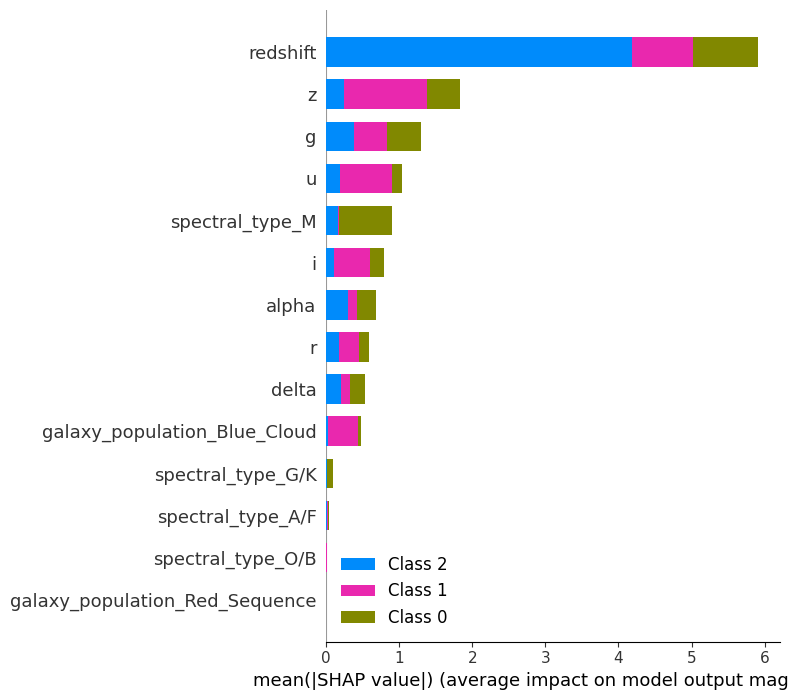

In [26]:
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

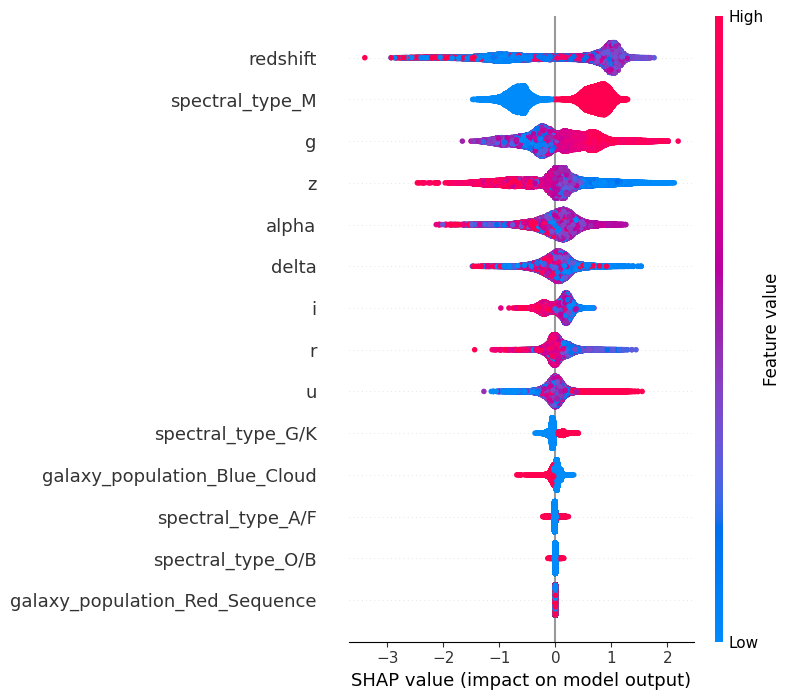

In [27]:
class_idx=0
shap.summary_plot(shap_values[:,:,class_idx], X_test_transformed_df)

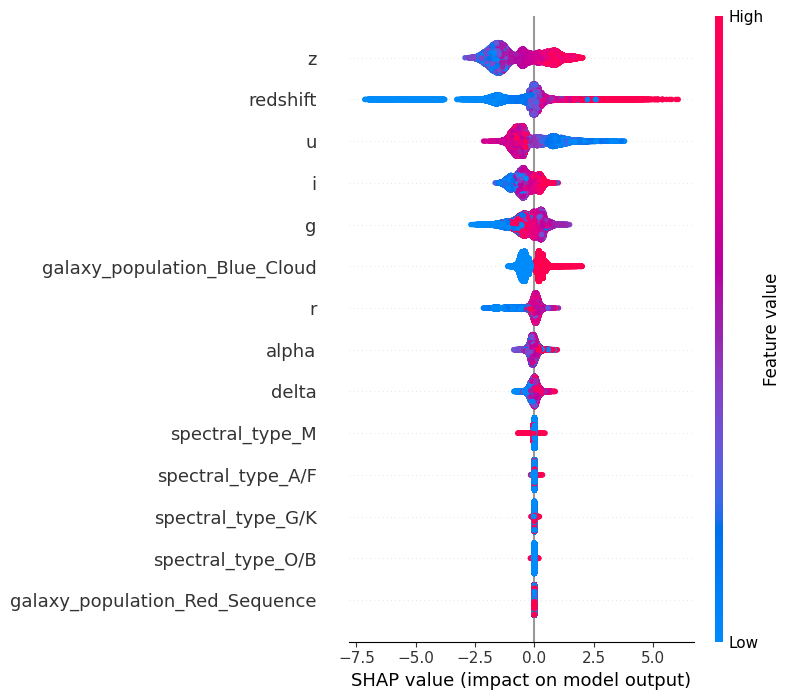

In [28]:
class_idx=1
shap.summary_plot(shap_values[:,:,class_idx], X_test_transformed_df)

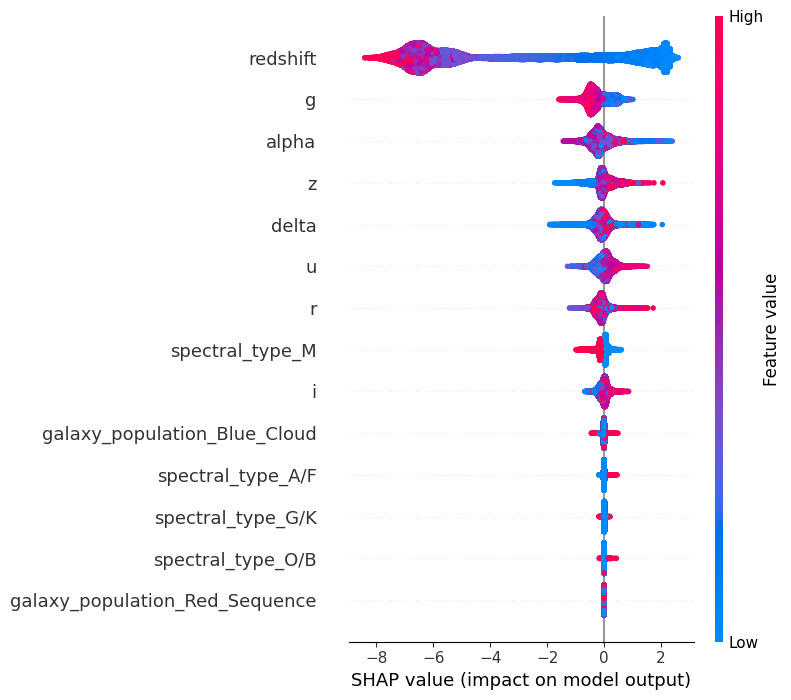

In [29]:
class_idx=2
shap.summary_plot(shap_values[:,:,class_idx], X_test_transformed_df)

In [30]:

import numpy as np
mean_abs_shap = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
top2_features = pd.Series(mean_abs_shap, index=all_feature_names).sort_values(ascending=False).head(2).index.tolist()
print("Top 2 features:", top2_features)


Top 2 features: ['redshift', 'g']


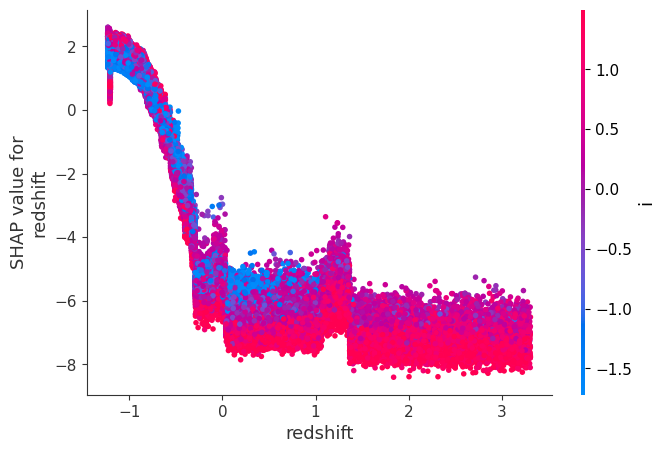

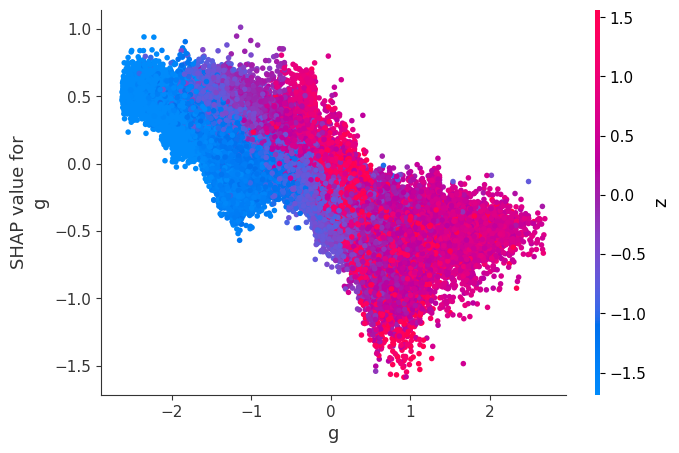

In [31]:
shap.dependence_plot(top2_features[0], shap_values[:, :, class_idx], X_test_transformed_df)
shap.dependence_plot(top2_features[1], shap_values[:, :, class_idx], X_test_transformed_df)

In [32]:
idx1, idx2 = 0, 1
shap.initjs()
base_value = explainer.expected_value[class_idx]
shap.plots.force(
    base_value,
    shap_values[idx1, :, class_idx],
    feature_names=all_feature_names
 )
shap.plots.force(
    base_value,
    shap_values[idx2, :, class_idx],
    feature_names=all_feature_names
 )

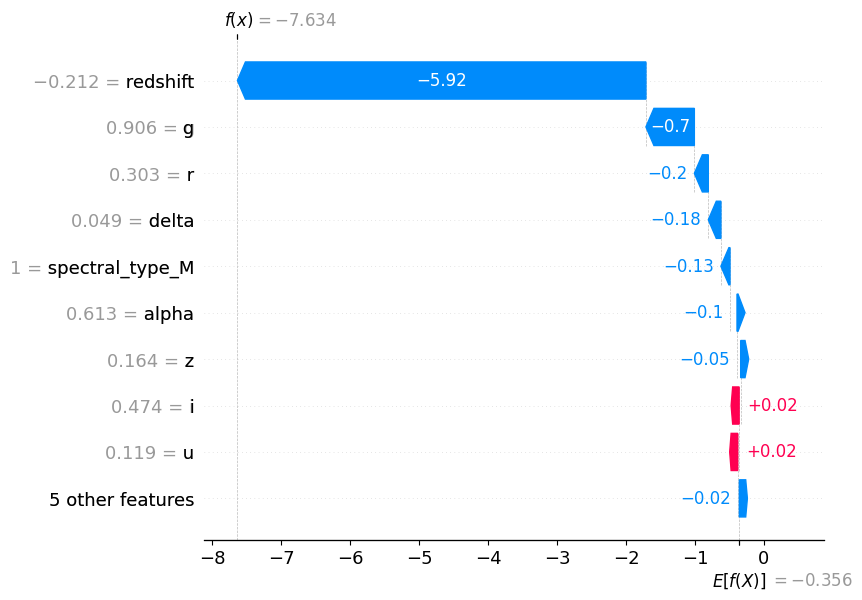

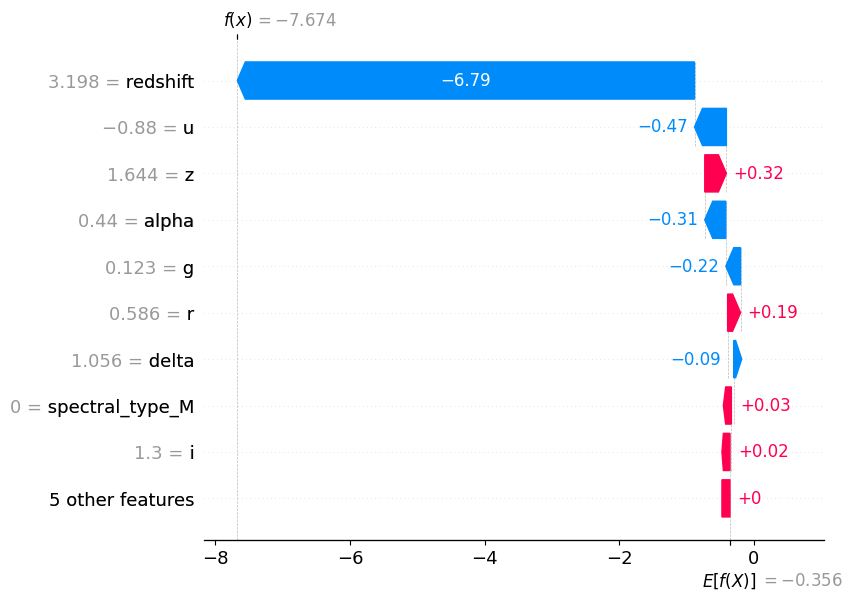

In [33]:

idx1, idx2 = 0, 1
base_value = explainer.expected_value[class_idx]

sample1_explanation = shap.Explanation(
    values=shap_values[idx1, :, class_idx],
    base_values=base_value,
    data=X_test_transformed_df.iloc[idx1].to_numpy(),
    feature_names=all_feature_names
 )
sample2_explanation = shap.Explanation(
    values=shap_values[idx2, :, class_idx],
    base_values=base_value,
    data=X_test_transformed_df.iloc[idx2].to_numpy(),
    feature_names=all_feature_names
 )

shap.plots.waterfall(sample1_explanation)
plt.show()

shap.plots.waterfall(sample2_explanation)
plt.show()

In [34]:
for idx in [idx1, idx2]:
    pred_class = le.classes_[fitted_classifier.predict(X_test_transformed_df.iloc[[idx]])[0]]
    true_class = le.classes_[y_test[idx]]
    print(f"Sample {idx}: Predicted={pred_class}, Actual={true_class}")

Sample 0: Predicted=GALAXY, Actual=GALAXY
Sample 1: Predicted=QSO, Actual=QSO


In [35]:
test_df=pd.read_csv("test.csv")
test_ids = test_df['id']
final_model = grid_search_xgb.best_estimator_
test_preds_encoded = final_model.predict(test_df)
test_preds_labels = le.inverse_transform(test_preds_encoded)

submission = pd.DataFrame({
    'id': test_ids,
    'class': test_preds_labels 
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [36]:
# finding the cross-validation accuracy and Kaggle Public Leaderboard Score
cv_scores = cross_val_score(final_model, X, y_encoded, cv=skf, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
print(f"Kaggle Public Leaderboard Score: <0.95296>")


Cross-Validation Accuracy: 0.9637 (± 0.0003)
Kaggle Public Leaderboard Score: <0.95296>


In [37]:
#saving the best model 
import joblib
joblib.dump(final_model, "stellar_classifier_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']